<a href="https://colab.research.google.com/github/amatsukami0420/AI_Lab_Assignments-CSC262/blob/main/LinearRegressionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NAME:** Muhammad Waleed Bin Anwar
# **REG NO:** FA24-BCS-110
# **SECTION:** 4C
[github link](https://github.com/amatsukami0420/AI_Lab_Assignments-CSC262)



In [1]:
!pip install ucimlrepo

# STEP 1:
## Selecting the dataset

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets

# metadata
print(student_performance.metadata)

# variable information
print(student_performance.variables)


{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

# STEP 2:
## Preprocessing

In [3]:
import pandas as pd

# Convert categorical features to numeric using One-Hot Encoding
X_processed = pd.get_dummies(X, drop_first=True)

# The target 'y' usually contains G1, G2, and G3.
# We typically want to predict the final grade (G3).
y_target = y['G3']

# STEP 3:
## Splitting

In [11]:
from sklearn.model_selection import train_test_split

# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_target, test_size=0.2, random_state=42
)

# STEP 4:
## Training the Model

In [12]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# STEP 5:
Predictions on Training dataset.

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the training data
y_train_pred = model.predict(X_train)

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# STEP: 6
Predictions on Testing data.

In [17]:
# Make predictions on the testing data
y_test_pred = model.predict(X_test)

# Calculate metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# STEP 7:
Display R-Squared and MSE of Training and Testing Data

In [18]:
# Create a dictionary of the results
results_data = {
    'Metric': ['Mean Squared Error (MSE)', 'R-squared (R2)'],
    'Training Results': [train_mse, train_r2],
    'Testing Results': [test_mse, test_r2]
}

# Convert to DataFrame and display
results_table = pd.DataFrame(results_data)
print(results_table.to_string(index=False))

                  Metric  Training Results  Testing Results
Mean Squared Error (MSE)          6.447648         8.189784
          R-squared (R2)          0.387449         0.160170


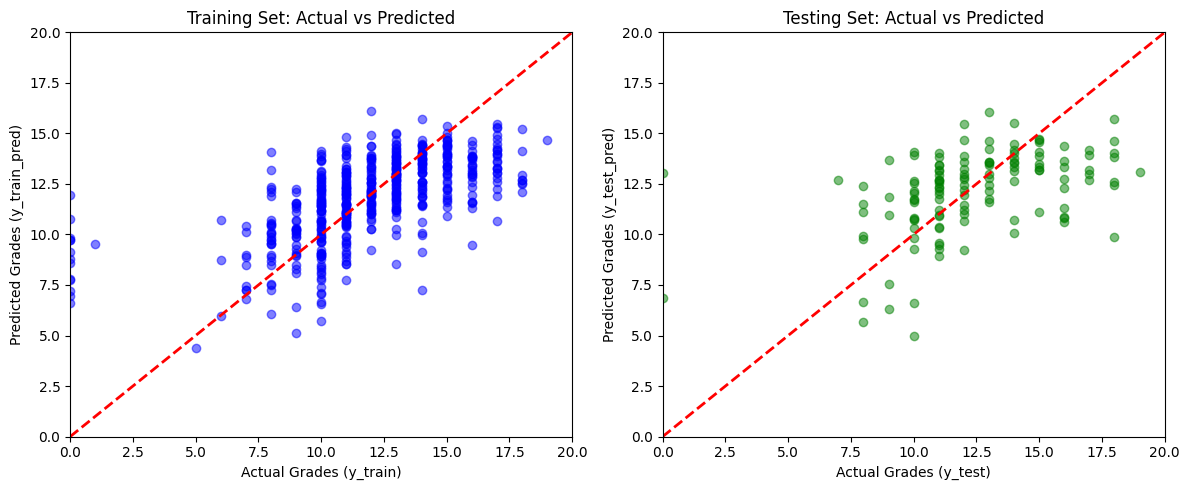

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot 1: Training Data
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.5)
plt.plot([0, 20], [0, 20], color='red', linestyle='--', linewidth=2) # Perfect fit line
plt.title('Training Set: Actual vs Predicted')
plt.xlabel('Actual Grades (y_train)')
plt.ylabel('Predicted Grades (y_train_pred)')
plt.xlim(0, 20)
plt.ylim(0, 20)

# Plot 2: Testing Data
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='green', alpha=0.5)
plt.plot([0, 20], [0, 20], color='red', linestyle='--', linewidth=2) # Perfect fit line
plt.title('Testing Set: Actual vs Predicted')
plt.xlabel('Actual Grades (y_test)')
plt.ylabel('Predicted Grades (y_test_pred)')
plt.xlim(0, 20)
plt.ylim(0, 20)

plt.tight_layout()
plt.show()